In [1]:
import pandas as pd

import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
matches = pd.read_csv(
    "../data/raw/matches.csv"
)

teams = pd.read_csv(
    "../data/raw/teams.csv"
)

matches.head()



,match_id,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,2,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,3,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,4,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,5,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
teams.head()

,team_id,country,continent,fifa_code
0,1,Abkhazia,Unknown,ABK
1,2,Afghanistan,Unknown,AFG
2,3,Albania,Unknown,ALB
3,4,Alderney,Unknown,ALD
4,5,Algeria,Unknown,ALG


In [4]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   match_id    49287 non-null  int64  
 1   date        49287 non-null  str    
 2   home_team   49287 non-null  str    
 3   away_team   49287 non-null  str    
 4   home_score  49215 non-null  float64
 5   away_score  49215 non-null  float64
 6   tournament  49287 non-null  str    
 7   city        49287 non-null  str    
 8   country     49287 non-null  str    
 9   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), int64(1), str(6)
memory usage: 6.2 MB


In [5]:
matches.shape

(49287, 10)

In [6]:
matches.isnull().sum()

match_id       0
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [7]:
matches.describe()

,match_id,home_score,away_score
count,49287.000000,49215.000000,49215.000000
mean,24644.000000,1.756091,1.182404
std,14228.075696,1.770617,1.401770
min,1.000000,0.000000,0.000000
25%,12322.500000,1.000000,0.000000
50%,24644.000000,1.000000,1.000000
75%,36965.500000,2.000000,2.000000
max,49287.000000,31.000000,21.000000


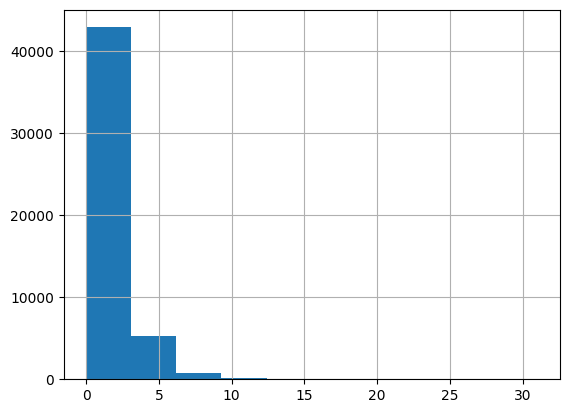

In [8]:
matches[
"home_score"
].hist(
bins=10
)

plt.show()

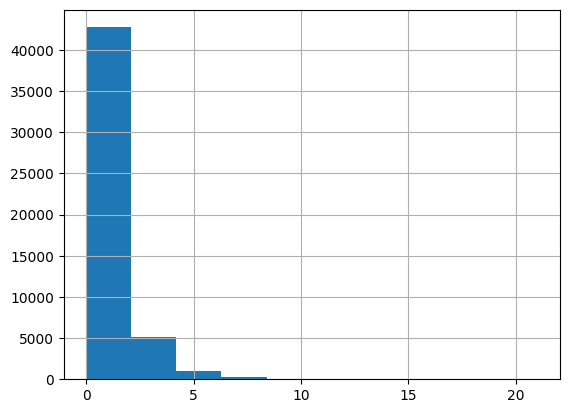

In [9]:
matches[
"away_score"
].hist(
bins=10
)

plt.show()

In [11]:
matches[
"total_goals"
] = (

matches.home_score

+

matches.away_score

)

matches[
"total_goals"
].head()

0    0.0
1    6.0
2    3.0
3    4.0
4    3.0
Name: total_goals, dtype: float64

In [12]:
matches[
"total_goals"
].mean()

np.float64(2.93849436147516)

In [13]:
home_count = (
matches[
"home_team"
]
.value_counts()
)

away_count = (
matches[
"away_team"
]
.value_counts()
)

games = (
home_count
+
away_count
)

games.head(20)

home_team
Abkhazia                 32.0
Afghanistan             144.0
Albania                 396.0
Alderney                135.0
Algeria                 618.0
Ambazonia                 NaN
American Samoa           55.0
Andalusia                13.0
Andorra                 226.0
Angola                  413.0
Anguilla                 91.0
Antigua and Barbuda     231.0
Arameans Suryoye         10.0
Argentina              1067.0
Armenia                 270.0
Artsakh                  11.0
Aruba                   151.0
Asturias                  NaN
Australia               582.0
Austria                 862.0
Name: count, dtype: float64

In [15]:
goals_home = (
matches
.groupby(
"home_team"
)
[
"home_score"
]
.sum()
)

goals_home.head()

goals_home.sort_values(
ascending=False
).head(10)

home_team
Brazil         1502.0
Germany        1380.0
Argentina      1344.0
England        1250.0
Sweden         1240.0
Mexico         1203.0
Netherlands    1136.0
Hungary        1130.0
France         1115.0
South Korea    1109.0
Name: home_score, dtype: float64

In [16]:
draws = matches[
matches.home_score
==
matches.away_score
]

In [17]:
len(draws)

11197

In [ ]:
(len(draws) / len(matches)) * 100

22.717958082252927